# Khám Phá Dữ Liệu

Notebook này dùng để phân tích dữ liệu CAMELS của ngân hàng đã được làm sạch từ BigQuery hoặc từ các file CSV đã xử lý trong `data/processed/`.

Mục tiêu của notebook:
- Kiểm tra độ thiếu dữ liệu và phạm vi giá trị của các biến
- Quan sát phân phối của các chỉ số CAMELS
- Xem mối tương quan giữa các biến tài chính quan trọng
- Ghi nhận sớm các vấn đề dữ liệu cần xử lý trước khi làm ML

## 1. Chuẩn Bị

Notebook này đọc dữ liệu đã làm sạch từ `data/processed/`, nên có thể chạy cục bộ mà không cần BigQuery.
Điều này giúp bạn xem kết quả EDA ngay trước khi đưa dữ liệu lên warehouse.

In [9]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.logger import get_logger

logger = get_logger(__name__)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titleweight"] = "bold"

In [10]:
processed_dir = PROJECT_ROOT / "data" / "processed"
fact_path = processed_dir / "fact_bank_performance_clean.csv"
dim_bank_path = processed_dir / "dim_bank_clean.csv"

fact_df = pd.read_csv(fact_path)
dim_bank_df = pd.read_csv(dim_bank_path)

df = fact_df.merge(
    dim_bank_df[["bank_key", "bank_code", "bank_name", "bank_type"]],
    on="bank_key",
    how="left",
)

logger.info("Đã tải %d dòng và %d cột từ các file CSV đã xử lý.", len(df), len(df.columns))
df.head()

2026-06-27 16:11:03 | INFO     | __main__ | Đã tải 667 dòng và 34 cột từ các file CSV đã xử lý.


,date_key,bank_key,total_assets,total_deposits,total_loans,total_equity,num_employees,num_branches,npl_amount,loan_loss_provision,...,cir,eta,etd,lta,ltd,gta,is_imputed,bank_code,bank_name,bank_type
0,20051231,1,679708.0,209317.0,406400.0,188076,94.0,NaN,17635.0,960.0,...,0.689223,0.276701,0.898522,0.597904,1.941553,0.597904,False,ABB,An Binh Commercial Joint Stock Bank,JSCB
1,20061231,1,3113898.0,1551159.0,1130930.0,1190274,309.0,14.0,30567.0,14430.0,...,0.759974,0.382246,0.767345,0.363188,0.729087,0.363188,False,ABB,An Binh Commercial Joint Stock Bank,JSCB
2,20071231,1,17174117.0,6776279.0,6858134.0,2479200,1123.0,54.0,103304.0,57849.0,...,0.801814,0.144357,0.365865,0.399330,1.012080,0.399330,False,ABB,An Binh Commercial Joint Stock Bank,JSCB
3,20081231,1,13494125.0,6673746.0,6538980.0,3955514,1345.0,70.0,81229.0,81229.0,...,0.958083,0.293129,0.592698,0.484580,0.979807,0.484580,False,ABB,An Binh Commercial Joint Stock Bank,JSCB
4,20091231,1,26518084.0,15001842.0,12882962.0,4489436,1717.0,86.0,142460.0,142460.0,...,0.763903,0.169297,0.299259,0.485818,0.858759,0.485818,False,ABB,An Binh Commercial Joint Stock Bank,JSCB


## 2. Tổng Quan Dữ Liệu

Các cell tiếp theo sẽ tóm tắt kích thước dữ liệu, kiểu dữ liệu, độ thiếu và các thống kê cơ bản.

In [11]:
display(df.info())
display(df.describe(include="all").T)

summary = pd.DataFrame({
    "cột": df.columns,
    "số_lượng_thiếu": df.isna().sum().values,
    "tỷ_lệ_thiếu_%": (df.isna().mean() * 100).round(2).values,
})
summary.sort_values("số_lượng_thiếu", ascending=False).reset_index(drop=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date_key              667 non-null    int64  
 1   bank_key              667 non-null    int64  
 2   total_assets          663 non-null    float64
 3   total_deposits        666 non-null    float64
 4   total_loans           665 non-null    float64
 5   total_equity          667 non-null    int64  
 6   num_employees         504 non-null    float64
 7   num_branches          468 non-null    float64
 8   npl_amount            612 non-null    float64
 9   loan_loss_provision   639 non-null    float64
 10  interest_income       662 non-null    float64
 11  interest_expense      662 non-null    float64
 12  net_interest_income   662 non-null    float64
 13  non_interest_expense  661 non-null    float64
 14  personnel_expense     531 non-null    float64
 15  other_expense         5

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date_key,667.0,NaN,NaN,NaN,20126988.121439,54058.869225,20021231.0,20081231.0,20121231.0,20171231.0,20221231.0
bank_key,667.0,NaN,NaN,NaN,23.73913,13.465929,1.0,12.0,24.0,35.0,45.0
total_assets,663.0,NaN,NaN,NaN,169960888.733032,296139776.9929,53869.0,18886042.5,67464850.0,169995735.0,2120609384.0
total_deposits,666.0,NaN,NaN,NaN,116881969.750751,225896004.103462,7314.0,8988342.75,38913862.0,112298444.75,1623935082.0
total_loans,665.0,NaN,NaN,NaN,108605860.493233,212158718.625509,50721.0,9959607.0,32042693.0,100621236.0,1483995823.0
total_equity,667.0,NaN,NaN,NaN,12478357.505247,18927917.321472,-370195.0,3027341.0,4841332.0,13563872.5,135646085.0
num_employees,504.0,NaN,NaN,NaN,6932.664683,8690.826311,45.0,1361.25,3161.5,8631.25,39950.0
num_branches,468.0,NaN,NaN,NaN,1613.632479,15651.140204,2.0,75.0,135.0,241.75,199689.0
npl_amount,612.0,NaN,NaN,NaN,2044874.294239,4112122.548685,-4637516.0,126394.5,571064.0,1924050.25,26064278.0
loan_loss_provision,639.0,NaN,NaN,NaN,1836426.611894,4319455.400631,-674646.0,85227.5,380182.0,1326333.0,38225891.0


,cột,số_lượng_thiếu,tỷ_lệ_thiếu_%
0,off_balance_sheet,217,32.53
1,num_branches,199,29.84
2,num_employees,163,24.44
3,personnel_expense,136,20.39
4,other_expense,134,20.09
5,npl_amount,55,8.25
6,loan_loss_provision,28,4.20
7,profit_before_tax,6,0.90
8,non_interest_expense,6,0.90
9,net_interest_income,5,0.75


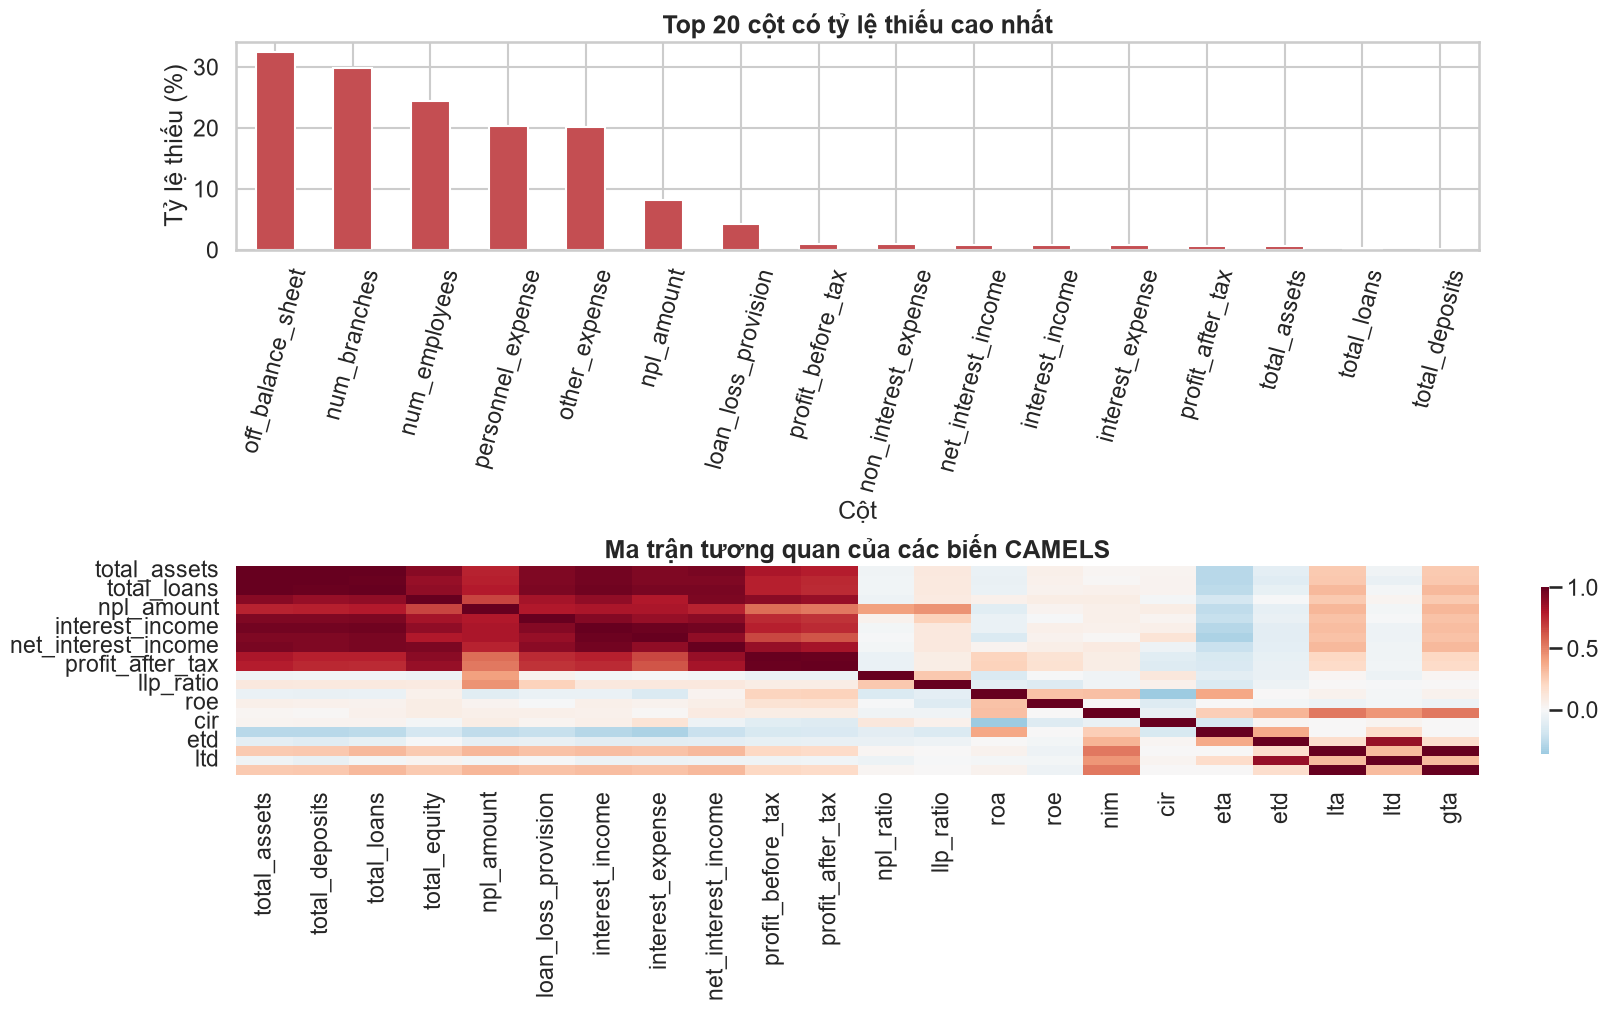

In [12]:
numeric_cols = [
    "total_assets", "total_deposits", "total_loans", "total_equity",
    "npl_amount", "loan_loss_provision", "interest_income", "interest_expense",
    "net_interest_income", "profit_before_tax", "profit_after_tax",
    "npl_ratio", "llp_ratio", "roa", "roe", "nim", "cir", "eta", "etd", "lta", "ltd", "gta"
]
available_numeric_cols = [col for col in numeric_cols if col in df.columns]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].head(20).plot(kind="bar", ax=axes[0], color="#c44e52")
axes[0].set_title("Top 20 cột có tỷ lệ thiếu cao nhất")
axes[0].set_ylabel("Tỷ lệ thiếu (%)")
axes[0].set_xlabel("Cột")
axes[0].tick_params(axis="x", rotation=75)

corr = df[available_numeric_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Ma trận tương quan của các biến CAMELS")
plt.show()

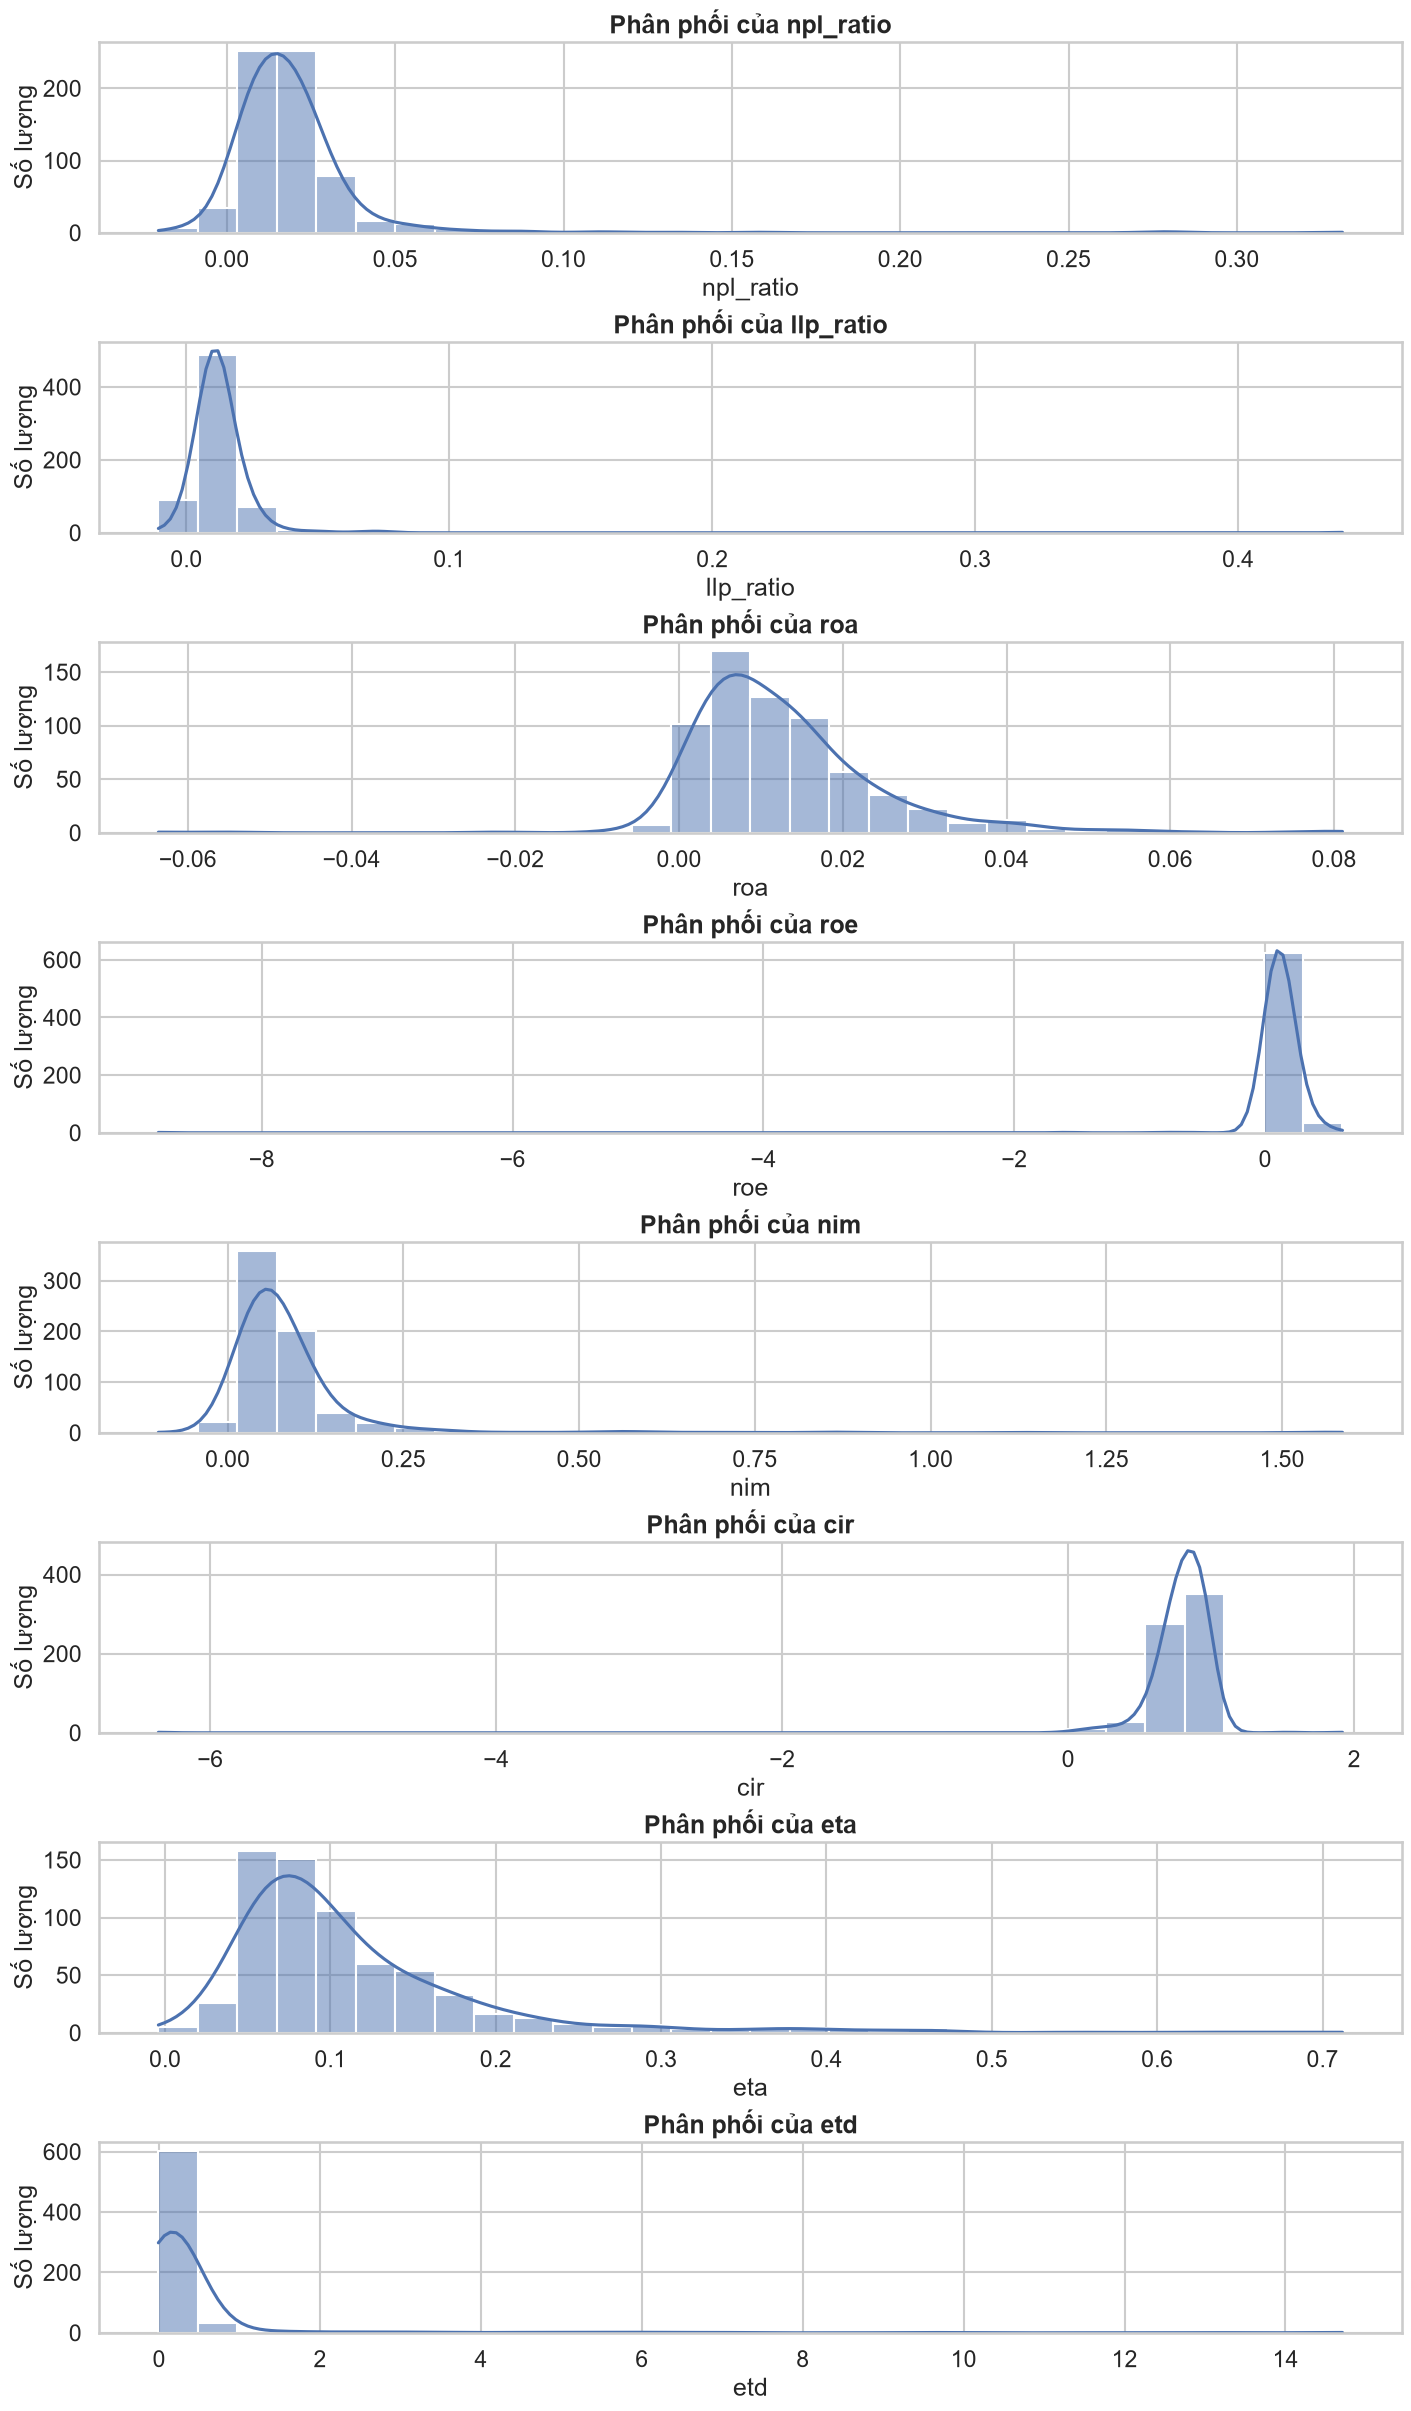

In [13]:
target_cols = ["npl_ratio", "llp_ratio", "roa", "roe", "nim", "cir", "eta", "etd"]
target_cols = [col for col in target_cols if col in df.columns]

fig, axes = plt.subplots(len(target_cols), 1, figsize=(14, 3 * len(target_cols)), constrained_layout=True)
if len(target_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, target_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#4c72b0")
    ax.set_title(f"Phân phối của {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Số lượng")

plt.show()

## 3. Kết Luận Nhanh

Dùng notebook này để phát hiện sớm:
- Cột thiếu nhiều dữ liệu
- Biến bị lệch phân phối hoặc có outlier
- Mối quan hệ mạnh giữa các chỉ số CAMELS
- Những ngân hàng hoặc năm có dữ liệu bất thường

## 4. Phân Tích Ngoại Lệ

Phần này kiểm tra các giá trị ngoại lệ bằng quy tắc IQR và vẽ boxplot cho các biến CAMELS quan trọng.

In [ ]:
outlier_cols = [
    "total_assets", "total_deposits", "total_loans", "total_equity",
    "npl_amount", "loan_loss_provision", "npl_ratio", "llp_ratio",
    "roa", "roe", "nim", "cir", "eta", "etd", "lta", "ltd", "gta"
]
outlier_cols = [col for col in outlier_cols if col in df.columns]

outlier_rows = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "cột": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "ngưỡng_dưới": lower,
        "ngưỡng_trên": upper,
        "số_outlier": int(mask.sum()),
        "tỷ_lệ_outlier_%": round(float(mask.mean() * 100), 2),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("số_outlier", ascending=False)
display(outlier_summary)

boxplot_cols = ["npl_ratio", "llp_ratio", "roa", "roe", "nim", "cir", "eta", "etd"]
boxplot_cols = [col for col in boxplot_cols if col in df.columns]

fig, axes = plt.subplots(len(boxplot_cols), 1, figsize=(14, 3 * len(boxplot_cols)), constrained_layout=True)
if len(boxplot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, boxplot_cols):
    sns.boxplot(x=df[col], ax=ax, color="#8da0cb")
    ax.set_title(f"Boxplot của {col}")
    ax.set_xlabel(col)

plt.show()